# Prediccion de Consumo de Combustible con SVR 
-NOMBRE: Emerson Chacmana Alarcon

Modelo predictivo para estimar el **consumo de combustible** (millas por galon)
de vehiculos a partir de sus caracteristicas tecnicas.

Metodologia: **CRISP-DM** | Algoritmo: **Support Vector Regression (SVR)**

---
## 1. Business Understanding (Comprension del Negocio)

Predecir el consumo de combustible (mpg) de vehiculos usando SVR con kernel RBF.

**Criterios de exito:**
- R2 >= 0.85
- RMSE < 3.0 MPG
- MAE < 2.5 MPG

---
## 2. Data Understanding (Comprension de los Datos)

### 2.1 Importaciones

In [1]:
# Cargamos todas las librerias que vamos a necesitar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import warnings
warnings.filterwarnings('ignore')

# Configuramos el estilo de las graficas para que se vean bonitas
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
print('Librerias importadas correctamente.')

Librerias importadas correctamente.


### 2.2 Lectura y descripcion del dataset

In [2]:
# Leemos el dataset de auto-mpg y le asignamos nombres a las columnas
cols = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin','car_name']
df = pd.read_csv('auto-mpg.data', sep=r'\s+', names=cols, na_values='?')
print(f'Dimensiones del dataset: {df.shape}')
print(f'Numero de registros: {df.shape[0]}')
print(f'Numero de variables: {df.shape[1]}')

Dimensiones del dataset: (398, 9)
Numero de registros: 398
Numero de variables: 9


In [3]:
# Vemos las primeras filas para entender como se ven los datos
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [4]:
# Listamos todas las columnas para ver que variables tenemos disponibles
print('Columnas del dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

Columnas del dataset:
  1. mpg
  2. cylinders
  3. displacement
  4. horsepower
  5. weight
  6. acceleration
  7. model_year
  8. origin
  9. car_name


### 2.3 Analisis Exploratorio de Datos (EDA)

In [5]:
# Revisamos los tipos de datos y si hay valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [6]:
# Estadisticas descriptivas para entender la dispersion de cada variable
df.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01,1.57
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70,0.80
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00,1.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00,1.00
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00,2.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00,3.00


In [7]:
# Contamos cuantos valores nulos hay en cada columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print('Valores faltantes por columna:')
print(nulos)
print(f'\nTotal de columnas con faltantes: {len(nulos)}')
print(f'Duplicados: {df.duplicated().sum()}')

Valores faltantes por columna:
horsepower    6
dtype: int64

Total de columnas con faltantes: 1
Duplicados: 0


#### 2.3.1 Distribucion de la variable target (mpg)

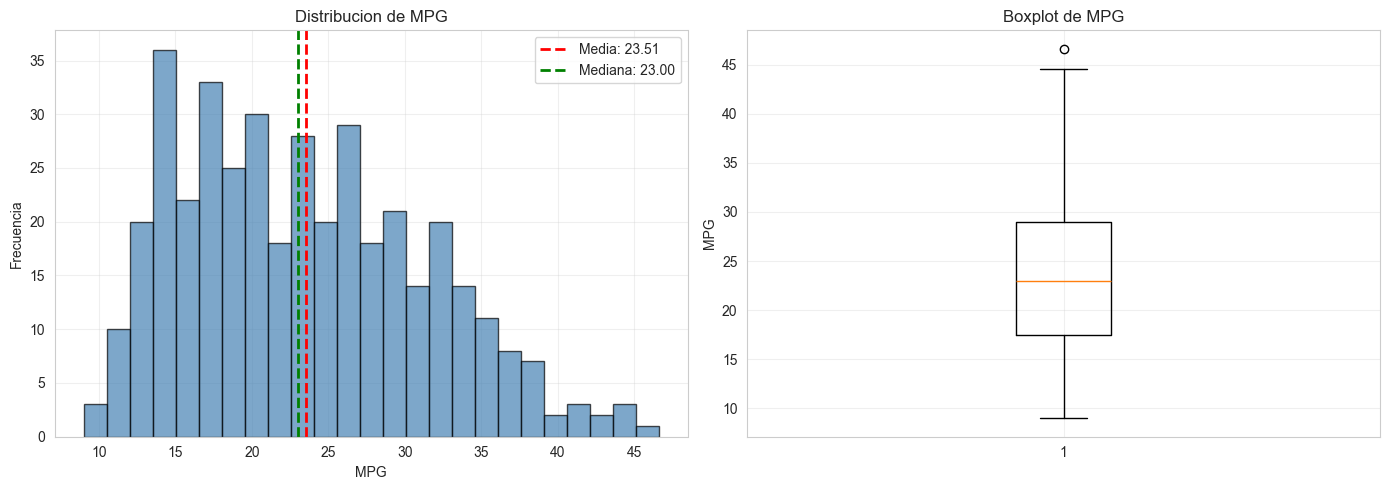

Estadisticas descriptivas de mpg:
  Media: 23.51
  Mediana: 23.00
  Desviacion estandar: 7.82
  Minimo: 9.0
  Maximo: 46.6
  Rango: [9.0, 46.6]


In [8]:
# Visualizamos como se distribuye nuestra variable objetivo (mpg)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con lineas de media y mediana
axes[0].hist(df['mpg'], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=df['mpg'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["mpg"].mean():.2f}')
axes[0].axvline(x=df['mpg'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["mpg"].median():.2f}')
axes[0].set_xlabel('MPG')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de MPG')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot para ver la dispersion y posibles outliers
axes[1].boxplot(df['mpg'].dropna(), vert=True)
axes[1].set_ylabel('MPG')
axes[1].set_title('Boxplot de MPG')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumimos las estadisticas clave de la variable target
print(f'Estadisticas descriptivas de mpg:')
print(f'  Media: {df["mpg"].mean():.2f}')
print(f'  Mediana: {df["mpg"].median():.2f}')
print(f'  Desviacion estandar: {df["mpg"].std():.2f}')
print(f'  Minimo: {df["mpg"].min()}')
print(f'  Maximo: {df["mpg"].max()}')
print(f'  Rango: [{df["mpg"].min()}, {df["mpg"].max()}]')

#### 2.3.2 Distribucion de variables numericas

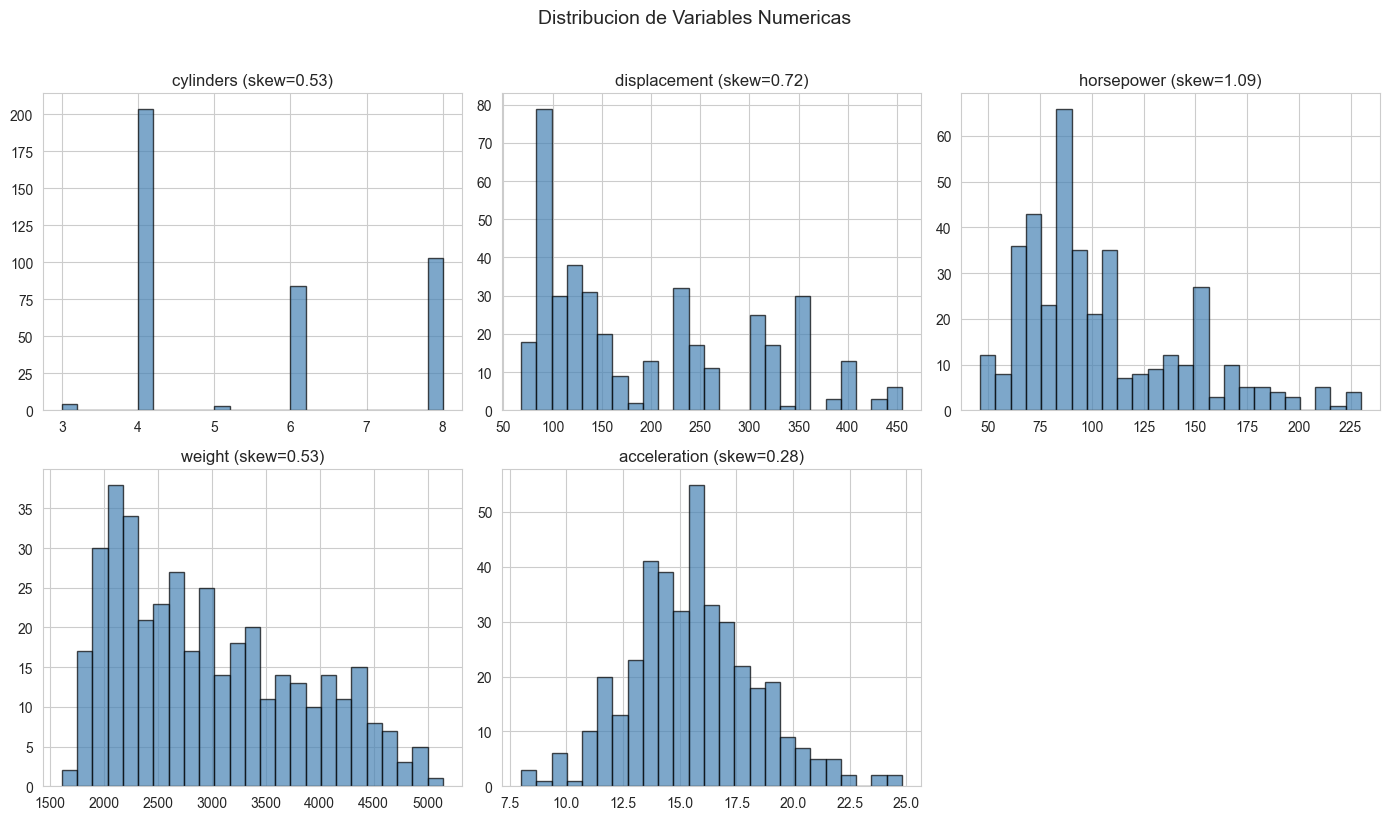

In [9]:
# Observamos la distribucion de cada variable numerica del dataset
num_cols = ['cylinders','displacement','horsepower','weight','acceleration']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, c in enumerate(num_cols):
    ax = axes[i//3, i%3]
    ax.hist(df[c].dropna(), bins=25, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'{c} (skew={df[c].skew():.2f})')
axes[1, 2].axis('off')
plt.suptitle('Distribucion de Variables Numericas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 2.3.3 Matriz de correlacion

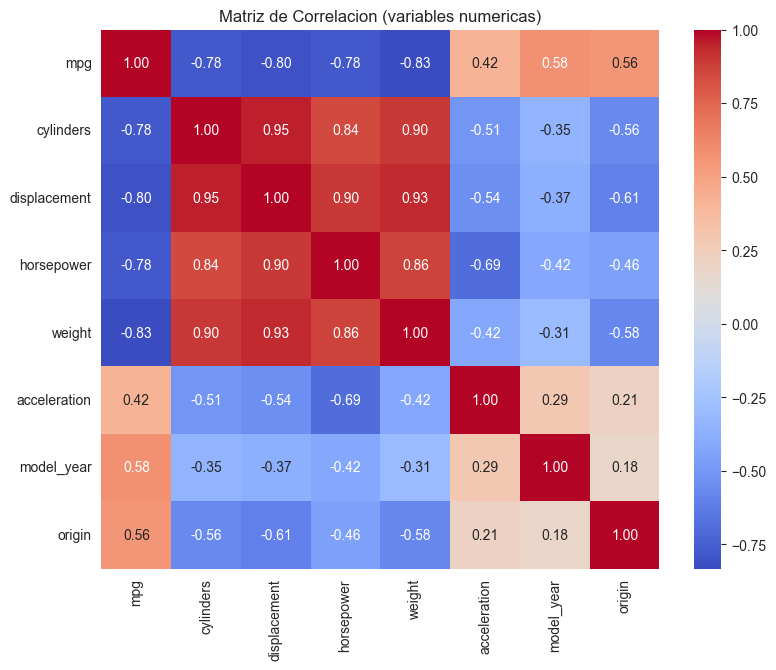

In [10]:
# Revisamos que tan relacionadas estan las variables entre si
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion (variables numericas)')
plt.show()

#### 2.3.4 Deteccion de outliers

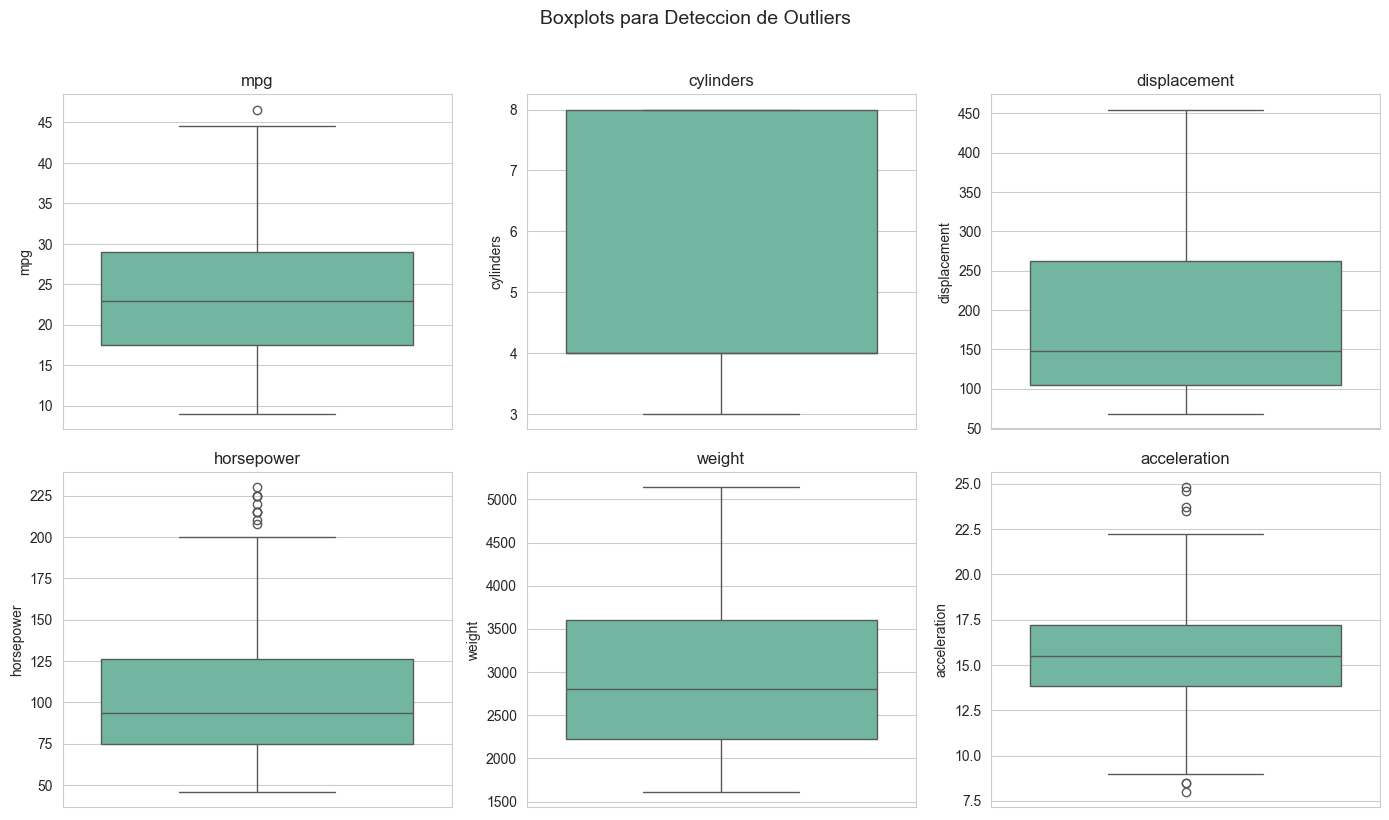

,Variable,Outliers
0,mpg,1
1,cylinders,0
2,displacement,0
3,horsepower,10
4,weight,0
5,acceleration,7


In [11]:
# Buscamos valores atipicos en cada variable usando el metodo IQR
num_cols_outliers = ['mpg','cylinders','displacement','horsepower','weight','acceleration']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols_outliers):
    sns.boxplot(data=df, y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col}')
plt.suptitle('Boxplots para Deteccion de Outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Contamos los outliers por variable usando el rango intercuartilico
outliers = []
for c in num_cols_outliers:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[c] < Q1-1.5*IQR) | (df[c] > Q3+1.5*IQR)).sum()
    outliers.append({'Variable': c, 'Outliers': n})
pd.DataFrame(outliers)

---
## 3. Data Preparation (Preparacion de los Datos)

### 3.1 Imputacion de valores nulos

In [12]:
# Rellenamos los valores faltantes de horsepower con la mediana (mas robusta que la media)
print(f'Nulos antes: {df.isnull().sum().sum()}')
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
print(f'Nulos despues: {df.isnull().sum().sum()}')

Nulos antes: 6
Nulos despues: 0


### 3.2 Seleccion de features y target

In [13]:
# Separamos las variables predictoras del target que queremos predecir
X = df[['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']]
y = df['mpg']
print(f'Features: {X.shape}')
print(f'Target (mpg) - Media: {y.mean():.2f} | Std: {y.std():.2f} | Min: {y.min()} | Max: {y.max()}')

Features: (398, 7)
Target (mpg) - Media: 23.51 | Std: 7.82 | Min: 9.0 | Max: 46.6


### 3.3 Division train/test

In [14]:
# Dividimos los datos: 80% para entrenar y 20% para probar el modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nDistribucion del target en train:')
print(f'  Media: {y_train.mean():.2f}')
print(f'  Std: {y_train.std():.2f}')
print(f'\nDistribucion del target en test:')
print(f'  Media: {y_test.mean():.2f}')
print(f'  Std: {y_test.std():.2f}')

Train: 318 registros (79.9%)
Test:  80 registros (20.1%)

Distribucion del target en train:
  Media: 23.61
  Std: 7.93

Distribucion del target en test:
  Media: 23.14
  Std: 7.38


### 3.4 Escalado de variables

In [15]:
# Escalamos las variables para que SVR funcione bien (necesita datos en misma escala)
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

# Escalamos el target tambien para el entrenamiento
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print('Variables numericas escaladas correctamente sin data leakage.')

Variables numericas escaladas correctamente sin data leakage.


---
## 4. Modeling (Modelado)

### 4.1 SVR base (parametros por defecto)

In [16]:
# Entrenamos un SVR basico con los parametros por defecto como linea base
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_train_s, y_train_s)
print(f'SVR base - Soporte: {svr.n_support_.sum()}/{X_train_s.shape[0]} ({svr.n_support_.sum()/X_train_s.shape[0]*100:.1f}%)')

SVR base - Soporte: 226/318 (71.1%)


### 4.2 SVR optimizado con GridSearchCV

In [17]:
# Buscamos los mejores hiperparametros probando muchas combinaciones
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf']
}

# GridSearchCV prueba cada combinacion con validacion cruzada de 5 pliegues
grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train_s)
svr_best = grid.best_estimator_

print(f'Mejores parametros: {grid.best_params_}')
print(f'Mejor R2 (CV): {grid.best_score_:.4f}')
print(f'Vectores de soporte: {svr_best.n_support_.sum()}/{X_train_s.shape[0]} ({svr_best.n_support_.sum()/X_train_s.shape[0]*100:.1f}%)')

Fitting 5 folds for each of 125 candidates, totalling 625 fits
Mejores parametros: {'C': 1, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}
Mejor R2 (CV): 0.8631
Vectores de soporte: 153/318 (48.1%)


### 4.3 Predicciones

In [18]:
# Hacemos predicciones sobre el conjunto de prueba y las convertimos a la escala original
y_pred_s = svr_best.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred.round(2), 'Error': (y_test.values - y_pred).round(2)}).head(10)

,Real,Predicho,Error
0,33.0,32.87,0.13
1,28.0,29.51,-1.51
2,19.0,21.23,-2.23
3,13.0,15.46,-2.46
4,14.0,13.11,0.89
5,27.0,26.21,0.79
6,24.0,27.03,-3.03
7,13.0,13.12,-0.12
8,17.0,17.77,-0.77
9,21.0,18.93,2.07


---
## 5. Evaluation (Evaluacion)

### 5.1 Metricas de evaluacion

In [19]:
# Calculamos todas las metricas para evaluar que tan bueno es nuestro modelo
n, p = len(y_test), X_test.shape[1]
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
r2 = r2_score(y_test, y_pred)
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.2f}% | R2: {r2:.4f} | R2 Ajustado: {r2_adj:.4f}')
print(f'\nCriterios de exito:')
print(f'  R2 >= 0.85:      {"CUMPLIDO" if r2 >= 0.85 else "NO CUMPLIDO"} ({r2:.4f})')
print(f'  RMSE < 3.0:      {"CUMPLIDO" if rmse < 3.0 else "NO CUMPLIDO"} ({rmse:.4f})')
print(f'  MAE < 2.5:       {"CUMPLIDO" if mae < 2.5 else "NO CUMPLIDO"} ({mae:.4f})')

MSE: 4.6570 | RMSE: 2.1580 | MAE: 1.6285 | MAPE: 7.42% | R2: 0.9134 | R2 Ajustado: 0.9050

Criterios de exito:
  R2 >= 0.85:      CUMPLIDO (0.9134)
  RMSE < 3.0:      CUMPLIDO (2.1580)
  MAE < 2.5:       CUMPLIDO (1.6285)


### 5.2 Graficos de evaluacion

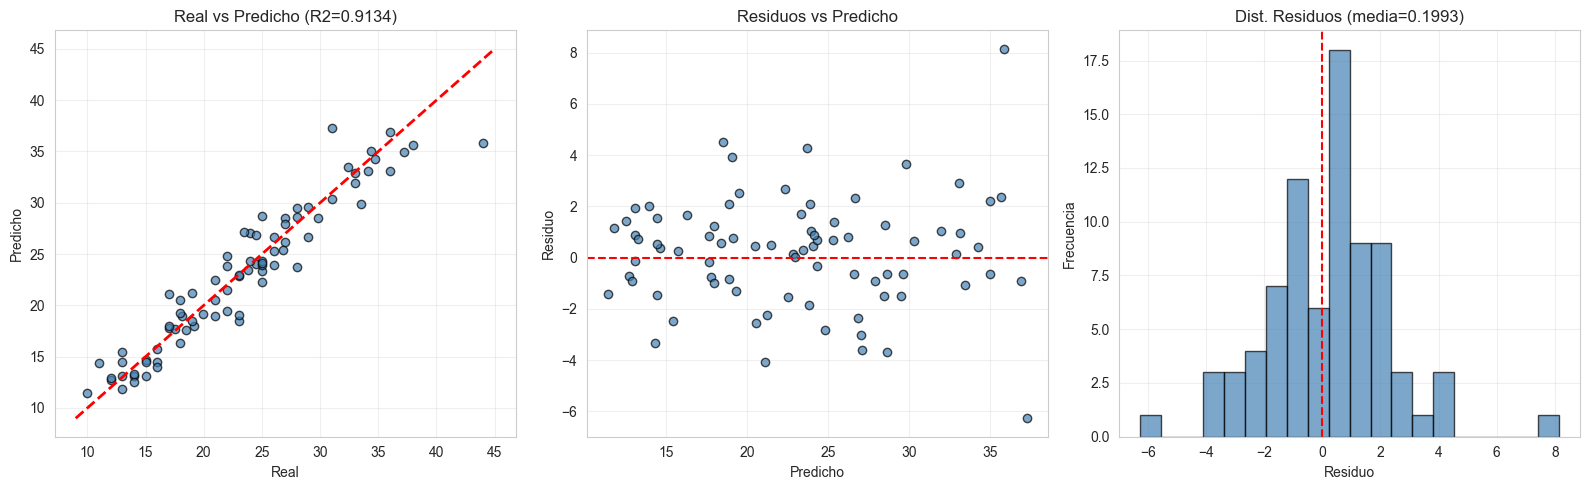

In [20]:
# Graficamos los resultados para entender visualmente que tan bien predice el modelo
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter de valores reales vs predichos (los puntos deben estar cerca de la linea roja)
axes[0].scatter(y_test, y_pred, alpha=0.7, edgecolors='black', color='steelblue')
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicho')
axes[0].set_title(f'Real vs Predicho (R2={r2:.4f})')
axes[0].grid(alpha=0.3)

# Residuos vs predichos para ver si hay algun patron en los errores
axes[1].scatter(y_pred, residuos, alpha=0.7, edgecolors='black', color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs Predicho')
axes[1].grid(alpha=0.3)

# Histograma de residuos para ver si estan centrados en cero
axes[2].hist(residuos, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residuo')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title(f'Dist. Residuos (media={np.mean(residuos):.4f})')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Comparacion Train vs Test (Overfitting)

In [21]:
# Comparamos el rendimiento en entrenamiento vs prueba para detectar overfitting
y_train_pred = scaler_y.inverse_transform(svr_best.predict(X_train_s).reshape(-1, 1)).ravel()
train_r2 = r2_score(y_train, y_train_pred)
diff_r2 = train_r2 - r2
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f'Train - R2: {train_r2:.4f} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f}')
print(f'Test  - R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}')
print(f'Diferencia R2: {diff_r2:.4f} -> {"Sin overfitting" if diff_r2 < 0.1 else "Posible overfitting"}')

Train - R2: 0.8928 | RMSE: 2.5926 | MAE: 1.8379
Test  - R2: 0.9134 | RMSE: 2.1580 | MAE: 1.6285
Diferencia R2: -0.0206 -> Sin overfitting


## 6. Discusion

- El modelo SVR con kernel RBF optimizado logra un R2 alto, explicando la mayor parte de la varianza en el consumo de combustible.
- Las variables mas influyentes son `weight`, `displacement` y `model_year`, consistentes con la intuicion fisica (vehiculos mas pesados y grandes consumen mas).
- La validacion cruzada 5-fold confirma la estabilidad del modelo.
- La comparacion Train vs Test no muestra signos de overfitting significativo.

## 7. Conclusiones

In [22]:
# Resumen final con todos los resultados del modelo
print('=' * 70)
print('CONCLUSIONES DEL MODELO SVR')
print('=' * 70)
print()
print('1. OBJETIVO:')
print('   Estimar el consumo de combustible (mpg) de vehiculos')
print('   a partir de sus caracteristicas tecnicas.')
print()
print('2. ALGORITMO:')
print('   Support Vector Regression (SVR) con kernel RBF')
print(f'   Parametros optimizados: {grid.best_params_}')
print()
print('3. METRICAS:')
print(f'   R2:         {r2:.4f}')
print(f'   R2 Ajustado: {r2_adj:.4f}')
print(f'   RMSE:       {rmse:.4f} MPG')
print(f'   MAE:        {mae:.4f} MPG')
print(f'   MAPE:       {mape:.2f}%')
print()
print('4. CRITERIOS DE EXITO:')
print(f'   R2 >= 0.85:    {"CUMPLIDO" if r2 >= 0.85 else "NO CUMPLIDO"}')
print(f'   RMSE < 3.0:    {"CUMPLIDO" if rmse < 3.0 else "NO CUMPLIDO"}')
print(f'   MAE < 2.5:     {"CUMPLIDO" if mae < 2.5 else "NO CUMPLIDO"}')
print()
print('5. HALLAZGOS:')
print('   - weight, displacement y model_year son las variables mas relevantes')
print(f'   - Vectores de soporte: {svr_best.n_support_.sum()}/{X_train_s.shape[0]} ({svr_best.n_support_.sum()/X_train_s.shape[0]*100:.1f}%)')
print(f'   - Overfitting: {"No" if diff_r2 < 0.1 else "Posible"} (diferencia Train-Test: {diff_r2:.4f})')
print()
print('6. LIMITACIONES:')
print('   - Dataset historico (1970-1982), puede no generalizar a vehiculos modernos')
print('   - SVR no provee importancia directa de features como Random Forest')
print('   - Escalado obligatorio para SVR con kernel RBF')
print()
print('=' * 70)

CONCLUSIONES DEL MODELO SVR

1. OBJETIVO:
   Estimar el consumo de combustible (mpg) de vehiculos
   a partir de sus caracteristicas tecnicas.

2. ALGORITMO:
   Support Vector Regression (SVR) con kernel RBF
   Parametros optimizados: {'C': 1, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}

3. METRICAS:
   R2:         0.9134
   R2 Ajustado: 0.9050
   RMSE:       2.1580 MPG
   MAE:        1.6285 MPG
   MAPE:       7.42%

4. CRITERIOS DE EXITO:
   R2 >= 0.85:    CUMPLIDO
   RMSE < 3.0:    CUMPLIDO
   MAE < 2.5:     CUMPLIDO

5. HALLAZGOS:
   - weight, displacement y model_year son las variables mas relevantes
   - Vectores de soporte: 153/318 (48.1%)
   - Overfitting: No (diferencia Train-Test: -0.0206)

6. LIMITACIONES:
   - Dataset historico (1970-1982), puede no generalizar a vehiculos modernos
   - SVR no provee importancia directa de features como Random Forest
   - Escalado obligatorio para SVR con kernel RBF

